# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | bare Python triple loops | sequential timing baseline; its O(N²) cost caps the speedup sweep at N = 4096 |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles + one-pass softmax: reuse over redundancy |
| `GpuV3` | fused FlashAttention-1 forward | one kernel, resident Q tile, online softmax — the N×N matrix never exists |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [1]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline, TorchPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

Two CPU models split the two Stage-1 jobs.

**Profiling — `TorchPipeline`.** For the step-time distribution every stage,
attention included, runs as vectorized PyTorch ops, so the
`torch.profiler.record_function` shares reflect *algorithmic* cost, not
interpreter overhead. Attention is the only $O(N^2 D)$ step in the block;
projections and FFN are $O(N D^2)$, linear in N. Chart 1 shows exactly that
scaling: the attention share starts small at $N = 64$, where the FFN
dominates, grows through the FLOP-count crossover at
$N \approx 5.5D \approx 2800$, and owns the forward pass by the top of
the profile.

**Timing baseline — `CpuPipeline`.** The speedup sweep needs a sequential
reference, so there attention runs as bare Python triple loops — no BLAS,
no SIMD, no threads. Its $O(N^2 D)$ interpreter cost (~30 min per attention
pass at $N = 4096$) is what caps the speedup sweep.

In [2]:
# Correctness gate: both CPU models must match torch's SDPA oracle before
# they can serve as profiling / timing references.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    for m in (cpu_model, TorchPipeline().eval()):
        # CpuPipeline: fp64 python floats vs fp32; TorchPipeline: unfused vs fused
        torch.testing.assert_close(m(x), bench.sdpa_reference(m, x),
                                   atol=1e-4, rtol=1e-3)
print("CpuPipeline & TorchPipeline match the torch SDPA oracle")

CpuPipeline & TorchPipeline match the torch SDPA oracle


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:06 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:07 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:07 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:08 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:09 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:13 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:17 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


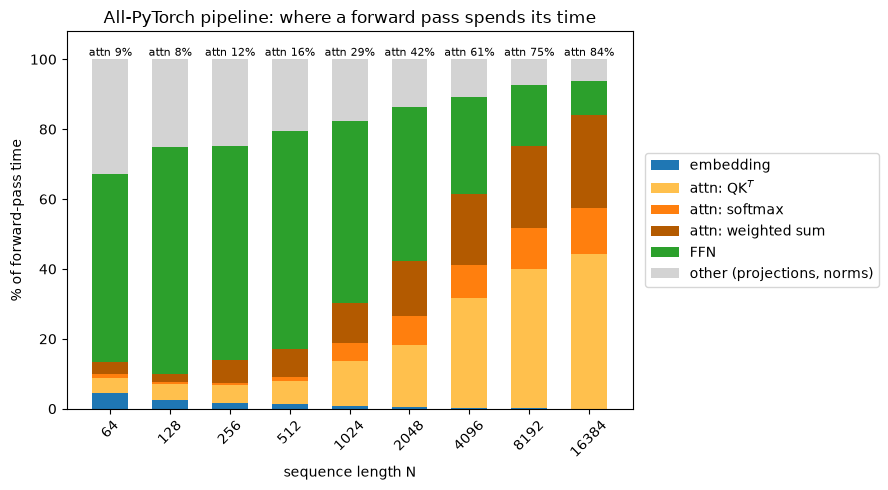

In [3]:
# Chart 1 -- share of forward-pass time per step (all-PyTorch pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 15)]
torch_model = TorchPipeline().eval()
pcts = [bench.step_percentages(torch_model, n) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("All-PyTorch pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Three versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse; V3 changes the algorithm so the traffic V2 was
economising never exists at all.

**V1 — naive three-launch** (`gpu_v1.py`): `_matmul` (QK$^T$, with the
$1/\sqrt{D}$ scale fused into the epilogue), `_softmax`, `_matmul`
(weights·V) — and every intermediate including the full N×N score matrix
round-trips through global memory. The matmul loads are coalesced (adjacent
threads read adjacent addresses) but nothing is reused, and the softmax
uses one block per row with a coalesced read but still passes over the row
three times (max, sum, write); V2 folds those into one pass.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from
global memory 16× less often; shared arrays are padded to dodge bank
conflicts) and fuses the $1/\sqrt{D}$ scaling into the epilogue.
`_softmax_online` uses one block per row: a running (max, sum) pair
rescaled when the max moves — the log-sum-exp trick — gets both out of
**one** coalesced read of the row.

**V3 — fused FlashAttention-1 forward** (`gpu_v3.py`): the whole step in one
kernel, and the $N \times N$ score matrix never exists in any memory. Each
block stages its 16-row Q tile in shared memory *once* and keeps it resident
while sweeping the K/V tiles — Q traffic drops from $O(N^2 D)$ to $O(N D)$.
Per 16×16 tile: the score tile $S = QK^T/\sqrt{D}$ is a shared-memory block
matmul (K and V staged chunk by chunk with exactly V2's tiling idiom — no
prefetching, no unrolling); then Algorithm 1 of the FlashAttention paper
runs verbatim — the tile's row max $\tilde{m}$ and sum $\tilde{l}$ merge
into the running $(m, l)$, and the output block is rescaled *and
renormalised* on the spot, so it always holds the exact softmax-weighted sum
of every key seen so far. Where V2 economised the N×N traffic, V3 deletes
it — at the price of one rescale-divide per tile, which FA-2 later showed
how to defer.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [4]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV2: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV3: matches torch SDPA within 1e-4


### Distribution shift — the bottleneck moves back

Same buckets for all four pipelines: attention as a single step, since the
GPU versions don't split it into sub-steps (and their attention time includes
the CPU↔GPU transfers — the honest cost of the swap); the all-PyTorch panel
reuses Chart 1's measurements. Moving attention to the GPU flips Chart 1: the
$O(N^2)$ step drops out of the distribution and the forward pass belongs to
the linear PyTorch steps again — until the $O(N^2)$ kernel time starts
creeping back in at the top of the sweep, the same scaling argument one level
down. V1, V2 and V3 differ only in the attention band, so each faster kernel
is directly visible as a thinner orange stripe.

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:20 8716

USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:21 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


...

USDT:2026-08-06 07:45:35 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:36 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:36 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 07:45:38 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:40 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


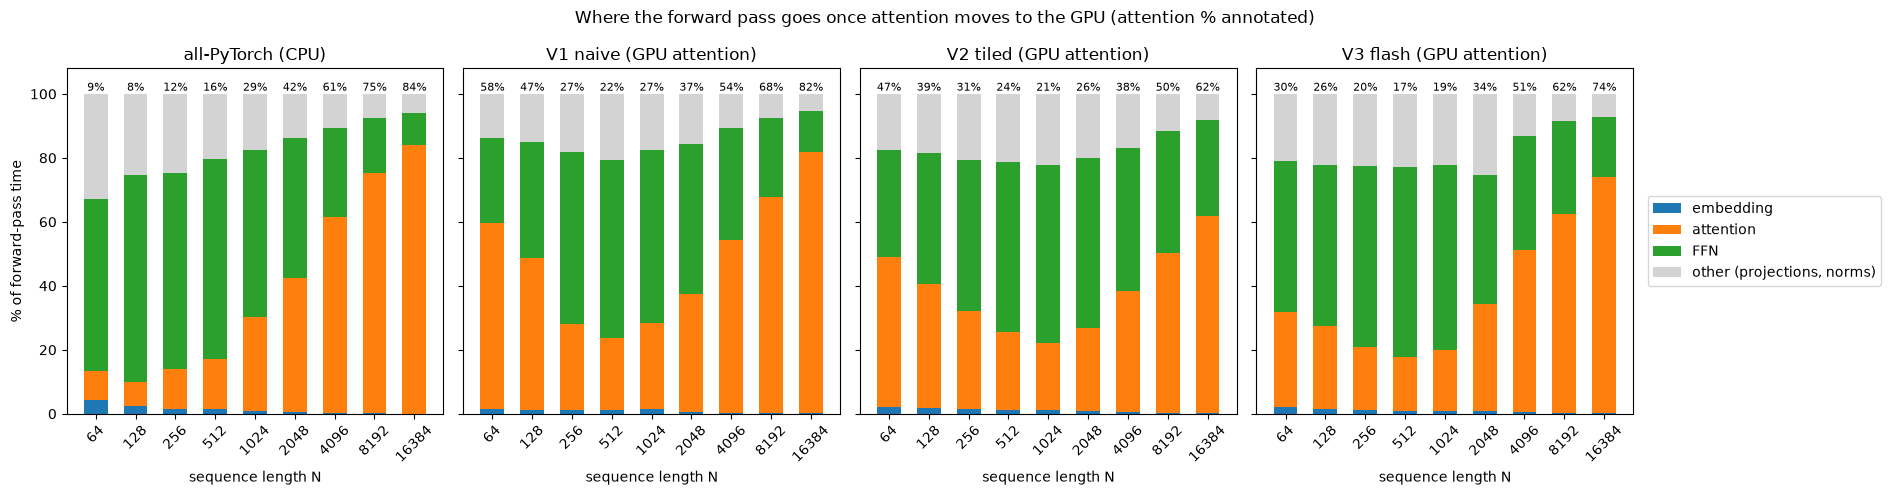

In [5]:
# Chart 1b -- step-time distribution per pipeline (coarse buckets, all comparable)
if cuda.is_available():
    # torch panel reuses Chart 1's profile: the sub-steps sum to the attention total
    dist = {"all-PyTorch (CPU)": [
        {"1_embedding": p["1_embedding"],
         "2_attention_total": sum(p[s] for s in bench.ATTN_STEPS),
         "3_ffn": p["3_ffn"], "other": p["other"]} for p in pcts]}
    for title, m in (("V1 naive (GPU attention)", GpuV1().eval()),
                     ("V2 tiled (GPU attention)", GpuV2().eval()),
                     ("V3 flash (GPU attention)", GpuV3().eval())):
        dist[title] = [bench.step_percentages(m, n, steps=bench.STEPS_TOTAL)
                       for n in PROFILE_LENS]
    torch.cuda.empty_cache()  # drop the dead N x N blocks the GPU passes leave cached

    parts = bench.STEPS_TOTAL + ["other"]
    names = {"1_embedding": "embedding", "2_attention_total": "attention",
             "3_ffn": "FFN", "other": "other (projections, norms)"}
    colors = {"1_embedding": "tab:blue", "2_attention_total": "tab:orange",
              "3_ffn": "tab:green", "other": "lightgray"}

    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(PROFILE_LENS))
    for ax, (title, ps) in zip(axes, dist.items()):
        bottom = np.zeros(len(PROFILE_LENS))
        for part in parts:
            vals = np.array([p[part] for p in ps])
            ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
            bottom += vals
        for xi, p in zip(xpos, ps):  # annotate the attention share
            ax.text(xi, 101, f"{p['2_attention_total']:.0f}%", ha="center", fontsize=8)
        ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.set_ylim(0, 108)
    axes[0].set_ylabel("% of forward-pass time")
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.suptitle("Where the forward pass goes once attention moves to the GPU (attention % annotated)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the combined step-share chart")

## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v. The GPU
columns *include* the CPU→GPU→CPU transfers — the true cost of swapping a
kernel into an otherwise-CPU pipeline. N sweeps the powers of two from
$2^6$ to $2^{12}$ (64 → 4096), covering every spec checkpoint
(128 / 512 / 2048); the top is set by the python-loop baseline, whose
$O(N^2 D)$ interpreter cost reaches ~30 min per pass at $N = 4096$. A
calibration pass projects that cost and warns when a sequence length would
not be feasible (cell timeout or RAM). The CPU column is one profiled pass
per point, which also yields the three sub-step times reused as Chart 2's
baselines. The kernel-only sweep below runs GPU-only, so it extends to
$2^{14}$ for the memory and throughput analyses.

In [6]:
SEQ_LENS = [2 ** x for x in range(6, 13)]   # speedup sweep: capped by the CPU
KERNEL_LENS = [2 ** x for x in range(6, 16)]   # GPU-only analyses sweep to 32768,
                                               # the last N before V1/V2 OOM

if cuda.is_available():
    classes = {"V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               "V3 flash fused": GpuV3,
               }
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # feasibility guard: the baseline is interpreted python with O(N^2 D)
    # cost -- calibrate one pass, project the sweep top against the cell
    # timeout and available RAM
    import os
    cal_ms = bench.attention_ms(cpu_model, 256, reps=1, warmup=False)
    proj_s = cal_ms * (SEQ_LENS[-1] / 256) ** 2 / 1e3
    ram = os.sysconf("SC_PHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
    need = 2 * SEQ_LENS[-1] ** 2 * 32  # scores + weights as python float lists
    if proj_s > 3300 or need > 0.6 * ram:
        print(f"WARNING: N = {SEQ_LENS[-1]} may not be feasible on the python "
              f"baseline: projected ~{proj_s / 60:.0f} min per attention pass, "
              f"~{need / 1e9:.1f} GB of {ram / 1e9:.0f} GB RAM")

    # CPU measured last (slowest by far): one profiled pass per point yields
    # the per-step times (Chart 2's baselines) and their sum, the CPU column
    cpu_steps = [bench.attention_step_ms(cpu_model, n) for n in SEQ_LENS]
    times = {"CPU": [sum(d.values()) for d in cpu_steps], **times}

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green"}

USDT:2026-08-06 07:45:49 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:50 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:50 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:51 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:51 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:45:56 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:45:56 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:46:20 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:46:20 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:48:05 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:48:05 87166:87166 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 07:55:26 87166:87166 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 07:55:26 87166:87166 ActivityProfilerController.cpp:415] profiler_start


     N                          CPU                    V1 naive   V2 tiled + online softmax              V3 flash fused
-----------------------------------------------------------------------------------------------------------------------
    64                    254.00 ms                     1.85 ms                     1.81 ms                     1.34 ms
   128                   1160.20 ms                     2.10 ms                     2.00 ms                     1.71 ms
   256                   5445.60 ms                     2.74 ms                     2.58 ms                     2.53 ms
   512                  23609.31 ms                     4.31 ms                     3.75 ms                     4.23 ms
  1024                 105143.25 ms                    10.67 ms                     6.72 ms                    11.01 ms
  2048                 440161.14 ms                    39.58 ms                    17.91 ms                    34.93 ms
  4096                1783072.90 ms     

USDT:2026-08-06 08:25:10 87166:87166 ActivityProfilerController.cpp:455] profiler_stop


## Attention kernel timing — compute only

How fast are the kernels once the transfers are taken out of the picture?
Following the HW02 methodology: **device-resident timing with CUDA events**, so
the timed region is pure compute — no CPU→GPU→CPU copy. This isolates kernel
speed from the pipeline-boundary tax that the end-to-end sweep pays.

In [7]:
# Kernel-only timing sweep (CUDA events, device-resident) -- GPU-only, so it
# runs past the CPU-capped benchmark to N = 2^14 for Charts 3-5
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs")

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               "V3 flash fused": GpuV3().eval(),
               }
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=10) for n in KERNEL_LENS]
              for name, m in kmodels.items()}
    # per-step kernel times (QK^T, softmax, weighted sum) for Chart 2 --
    # only the unfused versions expose the three step methods (V3 is one kernel)
    ksteps = {name: [bench.attention_kernel_step_ms(m, n, reps=10) for n in KERNEL_LENS]
              for name, m in kmodels.items() if "_step_qkt" in type(m).__dict__}
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(KERNEL_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: Tesla T4 | 40 SMs



     N                      V1 naive     V2 tiled + online softmax                V3 flash fused   (kernel-only ms)
------------------------------------------------------------------------------------------------
    64                      1.366 ms                      1.240 ms                      0.638 ms
   128                      1.344 ms                      1.235 ms                      0.662 ms
   256                      1.357 ms                      1.250 ms                      1.020 ms
   512                      1.765 ms                      1.249 ms                      1.741 ms
  1024                      7.820 ms                      3.068 ms                      7.419 ms
  2048                     35.003 ms                     14.318 ms                     28.811 ms
  4096                    152.347 ms                     65.315 ms                    100.346 ms
  8192                    620.353 ms                    258.440 ms                    372.501 ms
 16384    

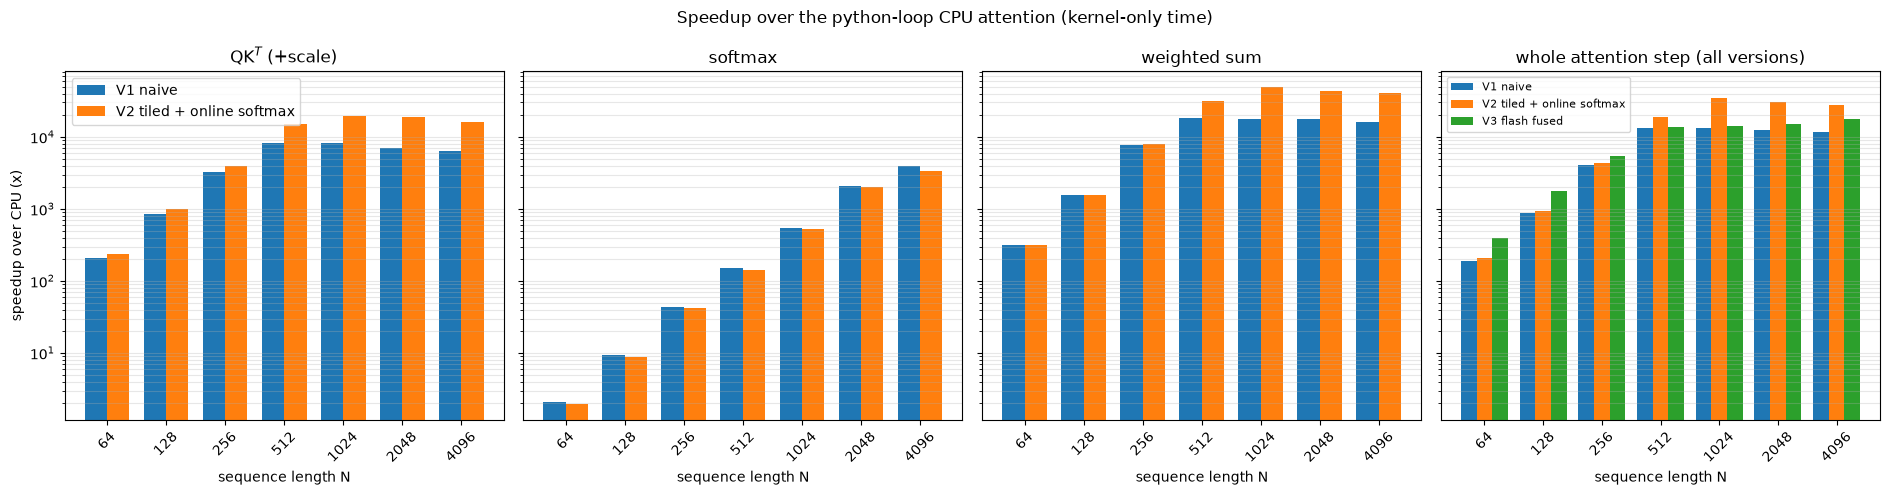

In [8]:
# Chart 2 -- speedup over the python-loop CPU attention: per sub-step for
# the unfused versions, then the whole step for all three (V3 is a single
# fused kernel, so whole-step granularity only)
if cuda.is_available():
    step_names = {"2a_qk_matmul": "QK$^T$ (+scale)", "2b_softmax": "softmax",
                  "2c_value_weighted_sum": "weighted sum"}
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(SEQ_LENS))
    w = 0.76 / len(ksteps)
    offs = (np.arange(len(ksteps)) - (len(ksteps) - 1) / 2) * w
    for ax, (step, title) in zip(axes, step_names.items()):
        for off, (name, ks) in zip(offs, ksteps.items()):
            kmap = dict(zip(KERNEL_LENS, ks))
            speedups = [c[step] / kmap[n][step] for c, n in zip(cpu_steps, SEQ_LENS)]
            ax.bar(xpos + off, speedups, w, color=COLORS[name], label=name)
        ax.set_yscale("log")
        ax.set_xticks(xpos, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, axis="y", which="both", alpha=0.3)

    ax = axes[-1]
    cpu_total = [sum(c.values()) for c in cpu_steps]
    w4 = 0.8 / len(ktimes)
    offs4 = (np.arange(len(ktimes)) - (len(ktimes) - 1) / 2) * w4
    for off, (name, kt) in zip(offs4, ktimes.items()):
        kmap = dict(zip(KERNEL_LENS, kt))
        speedups = [c / kmap[n] for c, n in zip(cpu_total, SEQ_LENS)]
        ax.bar(xpos + off, speedups, w4, color=COLORS[name], label=name)
    ax.set_yscale("log")
    ax.set_xticks(xpos, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_title("whole attention step (all versions)")
    ax.grid(True, axis="y", which="both", alpha=0.3)
    ax.legend(fontsize=8)

    axes[0].set_ylabel("speedup over CPU (x)")
    axes[0].legend()
    plt.suptitle("Speedup over the python-loop CPU attention (kernel-only time)")
    plt.tight_layout()
    plt.show()

## Measured kernel performance and hardware utilization

Ops and bytes from Nsight Compute (SASS thread-instruction counters for
fp32 FLOPs — fadd + fmul + 2·ffma; `dram__bytes.sum` for every transaction
crossing the DRAM boundary, refetches included — a one-off root-gated
collection cached in `dram_profile.json`), time from the boost-clock
CUDA-event kernel sweep. The pairing matters: ncu locks the GPU to base
clocks, so its own durations run ~2.3× the event sweep — the counts are
clock-independent and ride on the honest time. These analyses are GPU-only
and sweep to $N = 2^{15}$, the last size where V1/V2's N×N intermediates
still fit on the card.

Figure 1 shows the achieved *rates* — TFLOP/s against the fp32 ceiling,
GB/s against the DRAM ceiling. Figure 2 shows the same rates as
*utilization* of each ceiling. Raw counts and their floor ratios (the
$4N^2D$ FLOP floor; the compulsory Q, K, V + out byte floor) are in the
tables.

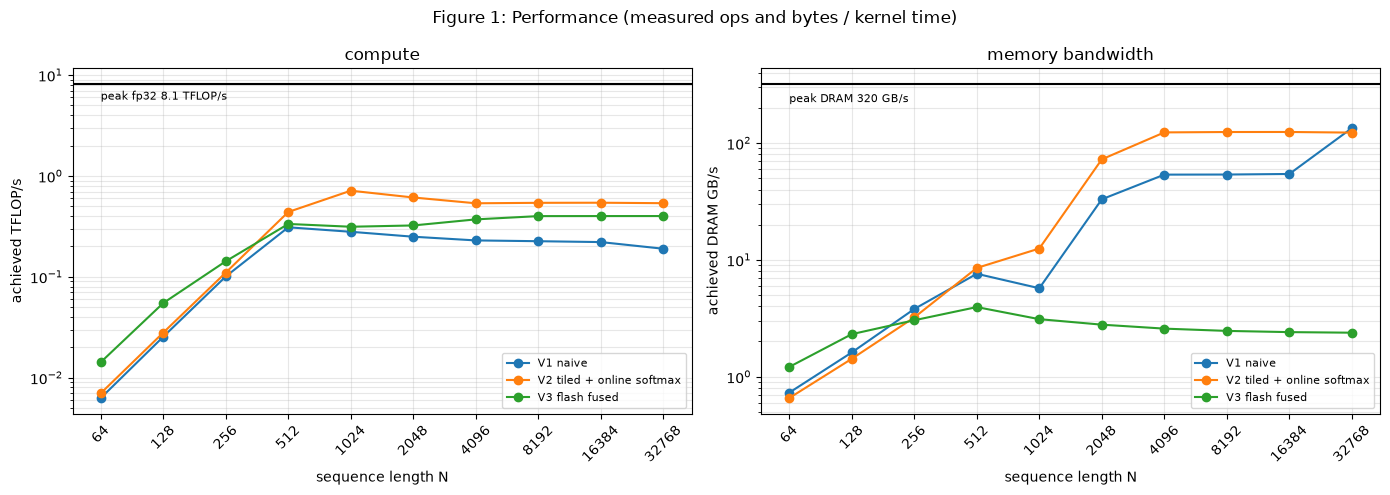

                   version      N     GFLOP  floor x  GB moved  floor x  TFLOP/s    GB/s


                  V1 naive  32768    2235.6   1.017x   1582.85  5896.6x     0.19   134.3


 V2 tiled + online softmax  32768    2235.9   1.017x    512.10  1907.7x     0.54   122.9


            V3 flash fused  32768    2380.5   1.083x     14.15    52.7x     0.40     2.4


In [9]:
# Figure 1: Performance -- achieved TFLOP/s and DRAM GB/s (measured counts
# over kernel-only CUDA-event time), against the hardware ceilings.
if cuda.is_available():
    import json, os, subprocess, sys
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    if not prof_path.exists():  # counters are root-gated: one-off sudo step
        cmd = ([] if os.geteuid() == 0 else ["sudo", "-n"]) + \
              [sys.executable, "src/dram_profile.py", "collect"]
        try:
            subprocess.run(cmd, check=True)
        except (subprocess.CalledProcessError, FileNotFoundError, PermissionError):
            print("no dram_profile.json and no counter access here -- run:")
            print("  sudo .venv/bin/python src/dram_profile.py collect")

    if prof_path.exists():
        prof = json.loads(prof_path.read_text())
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused"}
        specs = bench.gpu_specs()
        tmaps = {k: dict(zip(KERNEL_LENS, ktimes[pnames[k]])) for k in prof}

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for key, rows in prof.items():
            name = pnames[key]
            ns = [r["n"] for r in rows]
            tf = [r["flops"] / (tmaps[key][r["n"]] / 1e3) / 1e12 for r in rows]
            gb = [r["dram_bytes"] / (tmaps[key][r["n"]] / 1e3) / 1e9 for r in rows]
            axes[0].plot(ns, tf, marker="o", color=COLORS[name], label=name)
            axes[1].plot(ns, gb, marker="o", color=COLORS[name], label=name)
        axes[0].axhline(specs["tflops"], color="k", lw=1.5)
        axes[0].text(KERNEL_LENS[0], specs["tflops"] * 0.7,
                     f"peak fp32 {specs['tflops']:.1f} TFLOP/s", fontsize=8)
        axes[0].set_ylabel("achieved TFLOP/s")
        axes[0].set_title("compute")
        axes[1].axhline(specs["bw_gbs"], color="k", lw=1.5)
        axes[1].text(KERNEL_LENS[0], specs["bw_gbs"] * 0.7,
                     f"peak DRAM {specs['bw_gbs']:.0f} GB/s", fontsize=8)
        axes[1].set_ylabel("achieved DRAM GB/s")
        axes[1].set_title("memory bandwidth")
        for ax in axes:
            ax.set_xscale("log", base=2)
            ax.set_yscale("log")
            ax.set_xticks(KERNEL_LENS, KERNEL_LENS, rotation=45)
            ax.set_xlabel("sequence length N")
            ax.grid(True, which="both", alpha=0.3)
            ax.legend(fontsize=8)
        plt.suptitle("Figure 1: Performance (measured ops and bytes / kernel time)")
        plt.tight_layout()
        plt.show()

        print(f"{'version':>26} {'N':>6} {'GFLOP':>9} {'floor x':>8} "
              f"{'GB moved':>9} {'floor x':>8} {'TFLOP/s':>8} {'GB/s':>7}")
        for key, rows in prof.items():
            r = rows[-1]
            t_s = tmaps[key][r["n"]] / 1e3
            ff = bench.attention_flops(cpu_model, r["n"])
            fb = bench.attention_bytes(cpu_model, r["n"])
            print(f"{pnames[key]:>26} {r['n']:>6} {r['flops'] / 1e9:>9.1f} "
                  f"{r['flops'] / ff:>7.3f}x {r['dram_bytes'] / 1e9:>9.2f} "
                  f"{r['dram_bytes'] / fb:>7.1f}x {r['flops'] / t_s / 1e12:>8.2f} "
                  f"{r['dram_bytes'] / t_s / 1e9:>7.1f}")
else:
    print("No CUDA device -- skipping the performance figure")

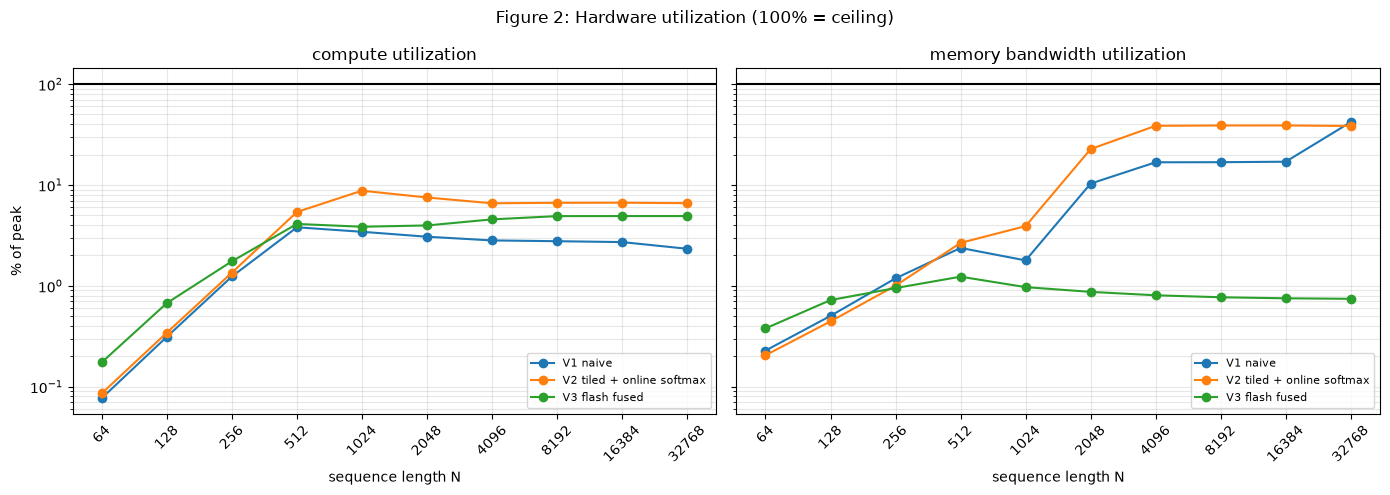

                   version      N  compute %  bandwidth %
                  V1 naive  32768       2.3%        41.9%
 V2 tiled + online softmax  32768       6.6%        38.4%
            V3 flash fused  32768       4.9%         0.7%


In [10]:
# Figure 2: Hardware utilization -- the same measured rates as % of each
# ceiling (fp32 compute peak, DRAM bandwidth peak).
if cuda.is_available():
    import json
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    prof = json.loads(prof_path.read_text()) if prof_path.exists() else {}
    if not prof or "flops" not in prof["v1"][0]:
        print("dram_profile.json lacks FLOP counters -- regenerate with:")
        print("  sudo .venv/bin/python src/dram_profile.py collect")
    else:
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused"}
        specs = bench.gpu_specs()
        tmaps = {k: dict(zip(KERNEL_LENS, ktimes[pnames[k]])) for k in prof}

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        for key, rows in prof.items():
            name = pnames[key]
            ns = [r["n"] for r in rows]
            cu = [100 * r["flops"] / (tmaps[key][r["n"]] / 1e3) / 1e12 / specs["tflops"]
                  for r in rows]
            bu = [100 * r["dram_bytes"] / (tmaps[key][r["n"]] / 1e3) / 1e9 / specs["bw_gbs"]
                  for r in rows]
            axes[0].plot(ns, cu, marker="o", color=COLORS[name], label=name)
            axes[1].plot(ns, bu, marker="o", color=COLORS[name], label=name)
        axes[0].set_title("compute utilization")
        axes[1].set_title("memory bandwidth utilization")
        axes[0].set_ylabel("% of peak")
        for ax in axes:
            ax.axhline(100.0, color="k", lw=1.5)
            ax.set_xscale("log", base=2)
            ax.set_yscale("log")
            ax.set_xticks(KERNEL_LENS, KERNEL_LENS, rotation=45)
            ax.set_xlabel("sequence length N")
            ax.grid(True, which="both", alpha=0.3)
            ax.legend(fontsize=8)
        plt.suptitle("Figure 2: Hardware utilization (100% = ceiling)")
        plt.tight_layout()
        plt.show()

        print(f"{'version':>26} {'N':>6} {'compute %':>10} {'bandwidth %':>12}")
        for key, rows in prof.items():
            r = rows[-1]
            t_s = tmaps[key][r["n"]] / 1e3
            cu = 100 * r["flops"] / t_s / 1e12 / specs["tflops"]
            bu = 100 * r["dram_bytes"] / t_s / 1e9 / specs["bw_gbs"]
            print(f"{pnames[key]:>26} {r['n']:>6} {cu:>9.1f}% {bu:>11.1f}%")
else:
    print("No CUDA device -- skipping the utilization figure")

## Arithmetic intensity — where each kernel lives on the roofline

Arithmetic intensity (AI) is FLOPs per DRAM byte — here *measured*, from the
same counters: executed fp32 ops over measured DRAM traffic. The ridge
point (peak FLOP/s ÷ peak bandwidth, ~25 FLOP/byte on the T4) divides the
regimes: above it a kernel could saturate compute before the bus; below it
the bus caps it first. The dotted line is the *algorithmic* AI — floor
FLOPs over compulsory bytes, $4N^2D / 16ND = N/4$ — what a perfect
implementation would achieve.

The gap between dotted and measured is each implementation's traffic waste:
V1 and V2 collapse from an algorithmic N/4 to a measured ~4 FLOP/byte —
every DRAM byte they move supports only a few operations (the N×N
round-trips and panel re-streams) — and V1 keeps falling, to 1.4 by
N = 32768, as its re-reads outgrow the L2 entirely: it ends the sweep
genuinely memory-bound. V3's
fusion keeps its measured AI two orders of magnitude higher and safely on
the compute side — the roofline's way of saying the bus is not its
problem, shared memory and occupancy are.

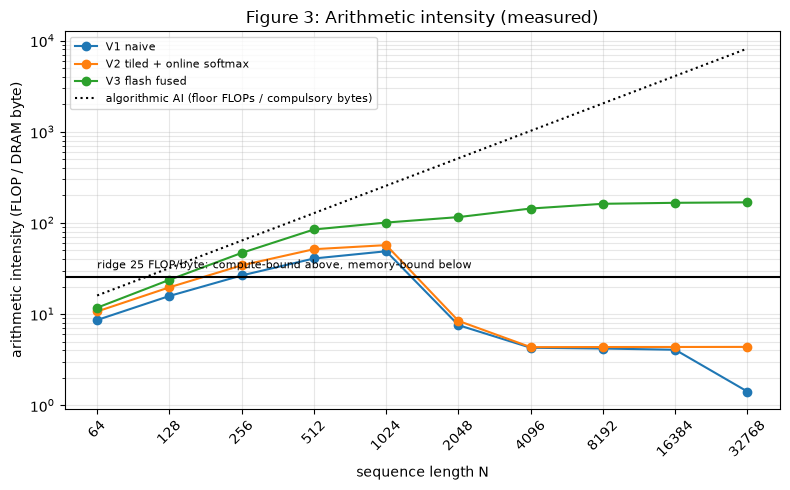

In [11]:
# Figure 3: Arithmetic intensity -- measured FLOPs per measured DRAM byte,
# vs the algorithmic AI (floor FLOPs / compulsory bytes = N/4) and the ridge.
if cuda.is_available():
    import json
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    prof = json.loads(prof_path.read_text()) if prof_path.exists() else {}
    if not prof or "flops" not in prof["v1"][0]:
        print("dram_profile.json lacks FLOP counters -- regenerate with:")
        print("  sudo .venv/bin/python src/dram_profile.py collect")
    else:
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused"}
        specs = bench.gpu_specs()
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            name = pnames[key]
            ax.plot([r["n"] for r in rows],
                    [r["flops"] / r["dram_bytes"] for r in rows],
                    marker="o", color=COLORS[name], label=name)
        alg = [bench.attention_flops(cpu_model, n) / bench.attention_bytes(cpu_model, n)
               for n in KERNEL_LENS]
        ax.plot(KERNEL_LENS, alg, "k:", label="algorithmic AI (floor FLOPs / compulsory bytes)")
        ridge = specs["tflops"] * 1e12 / (specs["bw_gbs"] * 1e9)
        ax.axhline(ridge, color="k", lw=1.5)
        ax.text(KERNEL_LENS[0], ridge * 1.25,
                f"ridge {ridge:.0f} FLOP/byte: compute-bound above, memory-bound below",
                fontsize=8)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(KERNEL_LENS, KERNEL_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("arithmetic intensity (FLOP / DRAM byte)")
        ax.set_title("Figure 3: Arithmetic intensity (measured)")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print("No CUDA device -- skipping the arithmetic-intensity figure")

## Memory footprint — the O(N²) wall

Traffic explains speed; footprint decides feasibility. The unfused versions
materialise the N×N score and weight matrices — $2N^2 \cdot 4$ bytes beyond
the inputs, quadrupling with every doubling of N — while V3 streams tiles
and allocates only the [N, D] output. The sweep runs past the analyses
above until the quadratic versions stop fitting on the card: the wall is
measured (torch allocator high-water mark, OOM caught), not modelled.

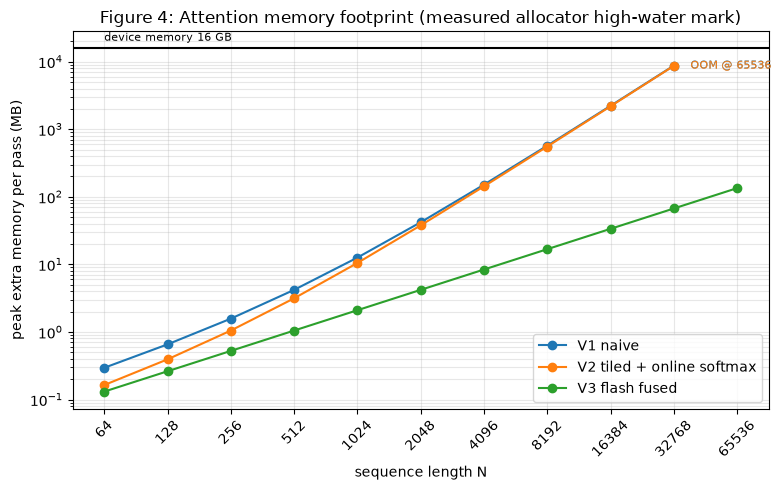

                  V1 naive: fits to N = 32768, OOM at N = 65536
 V2 tiled + online softmax: fits to N = 32768, OOM at N = 65536
            V3 flash fused: fits to N = 65536


In [12]:
# Figure 4: peak extra GPU memory of one attention pass, swept until the
# O(N^2) versions hit the card's capacity. None (OOM) ends a line.
if cuda.is_available():
    FOOT_LENS = [2 ** x for x in range(6, 17)]  # 64 .. 65536
    foot_models = {"V1 naive": GpuV1(), "V2 tiled + online softmax": GpuV2(),
                   "V3 flash fused": GpuV3()}
    foot = {name: [] for name in foot_models}
    for n in FOOT_LENS:
        for name, m in foot_models.items():
            foot[name].append(bench.attention_peak_extra_bytes(m, n))
        torch.cuda.empty_cache()

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, vals in foot.items():
        pts = [(n, b) for n, b in zip(FOOT_LENS, vals) if b is not None]
        xs, ys = [p[0] for p in pts], [p[1] / 1e6 for p in pts]
        ax.plot(xs, ys, marker="o", color=COLORS[name], label=name)
        if len(pts) < len(FOOT_LENS):  # line ends where the alloc stopped fitting
            ax.text(xs[-1] * 1.2, ys[-1], f"OOM @ {FOOT_LENS[len(pts)]}",
                    color=COLORS[name], fontsize=8, va="center")
    total = torch.cuda.get_device_properties(0).total_memory
    ax.axhline(total / 1e6, color="k", lw=1.5)
    ax.text(FOOT_LENS[0], total / 1e6 * 1.3, f"device memory {total / 1e9:.0f} GB",
            fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(FOOT_LENS, FOOT_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("peak extra memory per pass (MB)")
    ax.set_title("Figure 4: Attention memory footprint (measured allocator high-water mark)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    for name, vals in foot.items():
        fit = sum(b is not None for b in vals)
        print(f"{name:>26}: fits to N = {FOOT_LENS[fit - 1]}"
              + ("" if fit == len(FOOT_LENS) else f", OOM at N = {FOOT_LENS[fit]}"))
else:
    print("No CUDA device -- skipping the footprint sweep")

## Conclusion

Chart 1 picked the target — attention is the only step whose share of the
vectorized forward pass grows with N, crossing
$N \approx 5.5D \approx 2800$ to own it — and replacing just that step
takes N = 4096 attention from ~30 min on the python-loop baseline to 68 ms
with V2, transfers included (~2.6×10⁴×; V3 lands ~1.6×10⁴×, naive V1
~1.1×10⁴×). The headline is against a deliberately sequential interpreter:
it measures what leaving Python is worth, with torch SDPA kept only as the
correctness oracle every version must match within 1e-4.

The kernel ladder is a memory story, and the measured figures tell it end
to end. Chart 2 shows the speed rungs: V1 is coalesced but reuse-free —
every matmul operand re-read from global memory per output element — while
V2's 16×16 shared-memory tiles request ~16× fewer bytes for the same math
and its one-pass online softmax replaces V1's three passes: ~2.5× over V1
kernel-to-kernel (2.53 vs 1.03 s at N = 16384), the fastest kernel from
N = 512 up. Figures 1–3 (GPU-only, swept to $2^{15}$, the last size whose
N×N intermediates fit) show what happens when traffic outgrows the caches:
V1's re-reads explode to 1.58 TB per pass at N = 32768 — 5900× the
compulsory floor — its measured arithmetic intensity collapses to
1.4 FLOP/byte, far below the T4's ~25 ridge, and it ends the sweep
genuinely memory-bound, drawing 42% of the DRAM bus at 2.3% of compute.
V2's tiles hold the damage to 512 GB (1900× the floor, ~38% of the bus):
tiling economises on-chip requests, and past the L2 it merely slows the
bleeding. V3 — the FlashAttention-1 forward: resident Q tile, one fused
kernel, per-tile online softmax that rescales and renormalises the running
output — deletes the N×N traffic instead: 14 GB at N = 32768 (53× the
floor), measured AI ~170 — safely compute-side at ~1% of the bus — and
Figure 4's footprint stays O(N) where the others quadruple per doubling:
at N = 65536 V1 and V2 OOM the 16 GB card and V3 is the only version
still standing. Kernel-to-kernel V3 sits between the rungs (1.49 s at
N = 16384: ahead of V1 everywhere, behind V2 past N = 256) — the 1.08×
FLOP floor of its per-tile rescale-divides plus the 33 KB resident tile's
one-block-per-SM occupancy are the price of fusion.

All three versions run far from the fp32 ceiling — 2.3–6.6% of peak — and
on this card the remaining distance is not algorithmic: it is register
micro-tiling, vectorized loads and software pipelining, the machinery of
production GEMMs, unreachable from numba's scalar fp32 pipeline (Turing
has no fp32 tensor-core path). And fusion cannot be composed from library
calls — handing a library the matmuls means materialising N×N, the very
thing V3 exists to avoid — so a fused kernel must bring its own matmul:
V3's costs it speed against V2 and buys the only footprint and the only
arithmetic intensity that scale. The ladder ends where the programming
model does.